# ==========================================
# Global Conflict & Economic Impact Analysis
# Phase 2 : Conflict Analysis & EDA
# ==========================================

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use('ggplot')

pd.set_option('display.max_columns', None)

In [ ]:
conflict_df = pd.read_csv("clean_conflict.csv")

conflict_df.head()

,conflict_id,location,side_a,side_a_id,side_a_2nd,side_b,side_b_id,side_b_2nd,incompatibility,territory_name,year,intensity_level,cumulative_intensity,type_of_conflict,start_date,start_prec,start_date2,start_prec2,ep_end,ep_end_date,ep_end_prec,gwno_a,gwno_a_2nd,gwno_b,gwno_b_2nd,gwno_loc,region,version
0,200,Bolivia,Government of Bolivia,23,NaN,Popular Revolutionary Movement,719,NaN,2,NaN,1946,2,1,3,1946-07-18,1,1946-07-21,2,1,1946-07-21,NaN,145,NaN,NaN,NaN,145,5,26.1
1,200,Bolivia,Government of Bolivia,23,NaN,MNR,720,NaN,2,NaN,1949,1,1,3,1946-07-18,1,1949-09-15,3,1,1949-09-15,NaN,145,NaN,NaN,NaN,145,5,26.1
2,200,Bolivia,Government of Bolivia,23,NaN,MNR,720,NaN,2,NaN,1952,1,1,3,1946-07-18,1,1952-04-09,1,1,1952-04-12,NaN,145,NaN,NaN,NaN,145,5,26.1
3,200,Bolivia,Government of Bolivia,23,NaN,ELN,721,NaN,2,NaN,1967,1,1,3,1946-07-18,1,1967-03-31,3,1,1967-10-16,NaN,145,NaN,NaN,NaN,145,5,26.1
4,201,Cambodia (Kampuchea),Government of France,33,NaN,Khmer Issarak,160,NaN,1,Cambodia,1946,1,0,1,1946-08-31,3,1946-08-31,3,0,NaN,NaN,220,NaN,NaN,NaN,811,3,26.1


In [ ]:
print("Shape :", conflict_df.shape)

print("\nColumns\n")

print(conflict_df.columns.tolist())

Shape : (2816, 28)

Columns

['conflict_id', 'location', 'side_a', 'side_a_id', 'side_a_2nd', 'side_b', 'side_b_id', 'side_b_2nd', 'incompatibility', 'territory_name', 'year', 'intensity_level', 'cumulative_intensity', 'type_of_conflict', 'start_date', 'start_prec', 'start_date2', 'start_prec2', 'ep_end', 'ep_end_date', 'ep_end_prec', 'gwno_a', 'gwno_a_2nd', 'gwno_b', 'gwno_b_2nd', 'gwno_loc', 'region', 'version']


In [ ]:
conflict_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2816 entries, 0 to 2815
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   conflict_id           2816 non-null   int64  
 1   location              2816 non-null   object 
 2   side_a                2816 non-null   object 
 3   side_a_id             2816 non-null   object 
 4   side_a_2nd            479 non-null    object 
 5   side_b                2816 non-null   object 
 6   side_b_id             2816 non-null   object 
 7   side_b_2nd            147 non-null    object 
 8   incompatibility       2816 non-null   int64  
 9   territory_name        1586 non-null   object 
 10  year                  2816 non-null   int64  
 11  intensity_level       2816 non-null   int64  
 12  cumulative_intensity  2816 non-null   int64  
 13  type_of_conflict      2816 non-null   int64  
 14  start_date            2816 non-null   object 
 15  start_prec           

In [ ]:
conflict_df.isnull().sum()

,0
conflict_id,0
location,0
side_a,0
side_a_id,0
side_a_2nd,2337
side_b,0
side_b_id,0
side_b_2nd,2669
incompatibility,0
territory_name,1230


In [ ]:
conflict_df.describe(include='all')

,conflict_id,location,side_a,side_a_id,side_a_2nd,side_b,side_b_id,side_b_2nd,incompatibility,territory_name,year,intensity_level,cumulative_intensity,type_of_conflict,start_date,start_prec,start_date2,start_prec2,ep_end,ep_end_date,ep_end_prec,gwno_a,gwno_a_2nd,gwno_b,gwno_b_2nd,gwno_loc,region,version
count,2816.000000,2816,2816,2816,479,2816,2816,147,2816.000000,1586,2816.000000,2816.000000,2816.000000,2816.000000,2816,2816.000000,2816,2816.000000,2816.000000,563,0.0,2816,479,155,147,2816,2816,2.816000e+03
unique,NaN,165,121,121,172,671,679,43,NaN,145,NaN,NaN,NaN,NaN,293,NaN,573,NaN,NaN,479,NaN,121,164,36,38,165,12,NaN
top,NaN,Myanmar (Burma),Government of Myanmar (Burma),144,Government of United States of America,IS,234,Government of Vietnam (North Vietnam),NaN,Islamic State,NaN,NaN,NaN,NaN,1948-12-31,NaN,1964-12-31,NaN,NaN,1988-12-31,NaN,775,2,770,816,775,3,NaN
freq,NaN,308,308,308,26,167,167,18,NaN,152,NaN,NaN,NaN,NaN,111,NaN,79,NaN,NaN,8,NaN,308,31,30,19,308,1098,NaN
mean,1650.283736,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.458807,NaN,1992.877841,1.248580,0.720526,3.041903,NaN,2.126065,NaN,2.245739,0.199929,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.610000e+01
std,4010.873991,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.520016,NaN,21.500448,0.432266,0.448821,0.632190,NaN,1.597983,NaN,1.611675,0.400018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.842676e-13
min,200.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,1946.000000,1.000000,0.000000,1.000000,NaN,1.000000,NaN,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.610000e+01
25%,255.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,1977.000000,1.000000,0.000000,3.000000,NaN,1.000000,NaN,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.610000e+01
50%,309.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,1994.000000,1.000000,1.000000,3.000000,NaN,1.000000,NaN,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.610000e+01
75%,374.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,NaN,2013.000000,1.000000,1.000000,3.000000,NaN,3.000000,NaN,3.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.610000e+01


In [ ]:
total_conflicts = conflict_df['conflict_id'].nunique()

print("Total Unique Conflicts :", total_conflicts)

Total Unique Conflicts : 303


In [ ]:
countries = conflict_df['location'].nunique()

print("Countries Involved :", countries)

Countries Involved : 165


In [ ]:
yearly_conflicts = (
    conflict_df.groupby('year')
    .size()
    .reset_index(name='Conflict_Count')
)

yearly_conflicts.head()

,year,Conflict_Count
0,1946,17
1,1947,14
2,1948,20
3,1949,21
4,1950,18


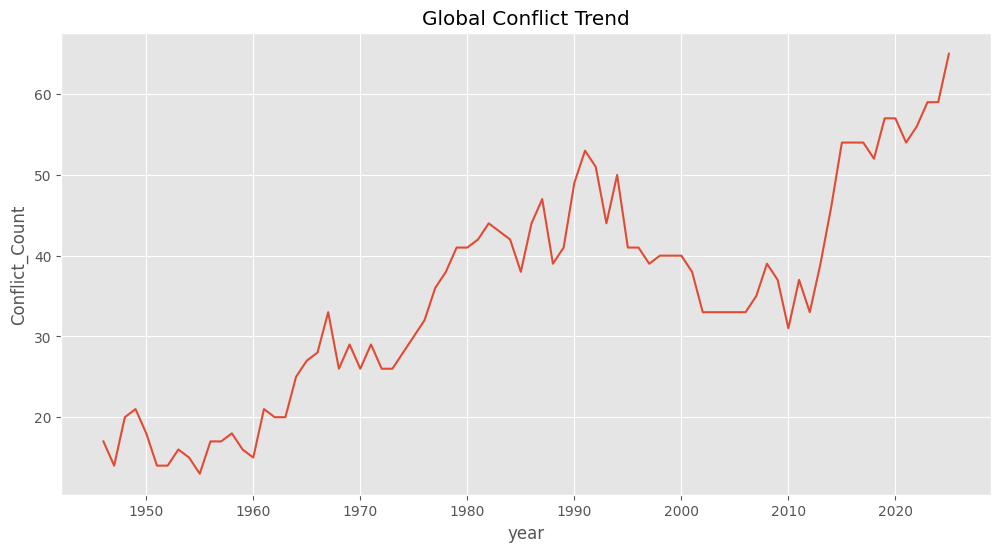

In [ ]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=yearly_conflicts,
    x='year',
    y='Conflict_Count'
)

plt.title("Global Conflict Trend")
plt.show()

In [ ]:
fig = px.line(
    yearly_conflicts,
    x='year',
    y='Conflict_Count',
    title='Global Conflict Trend'
)

fig.show()

In [ ]:
top_countries = (
    conflict_df['location']
    .value_counts()
    .head(15)
)

top_countries

,count
location,
Myanmar (Burma),308
India,190
Ethiopia,134
Philippines,122
Israel,85
Iraq,67
Colombia,62
Angola,59
Afghanistan,59


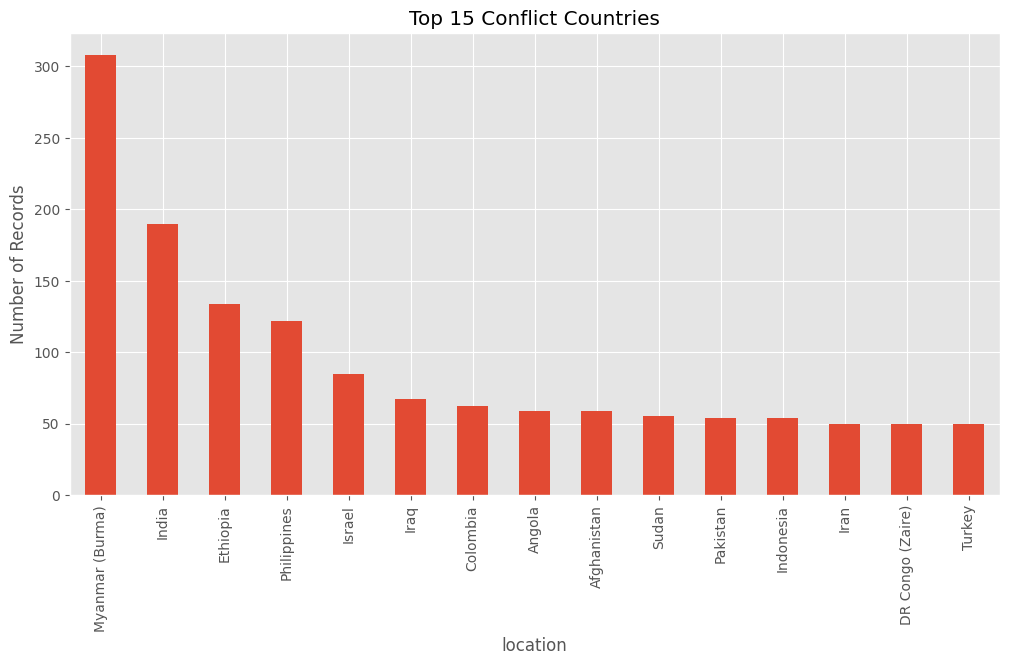

In [ ]:
plt.figure(figsize=(12,6))

top_countries.plot(
    kind='bar'
)

plt.title("Top 15 Conflict Countries")
plt.ylabel("Number of Records")

plt.show()

In [ ]:
fig = px.bar(
    x=top_countries.index,
    y=top_countries.values,
    title="Top 15 Conflict Countries"
)

fig.show()

In [ ]:
conflict_df['intensity_level'].value_counts()

,count
intensity_level,
1,2116
2,700


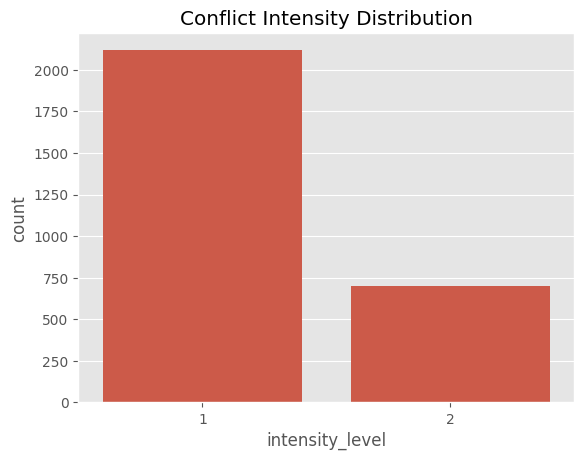

In [ ]:
sns.countplot(
    data=conflict_df,
    x='intensity_level'
)

plt.title("Conflict Intensity Distribution")

plt.show()

In [ ]:
country_intensity = (
    conflict_df.groupby('location')
    ['intensity_level']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

country_intensity

,intensity_level
location,
"Afghanistan, United Kingdom, United States of America",2.0
"Chad, Libya",2.0
"Australia, Iraq, United Kingdom, United States of America",2.0
"Cyprus, Turkey",2.0
Costa Rica,2.0
"Russia (Soviet Union), Ukraine",2.0
Vietnam (North Vietnam),2.0
South Vietnam,2.0
"South Vietnam, Vietnam (North Vietnam)",2.0


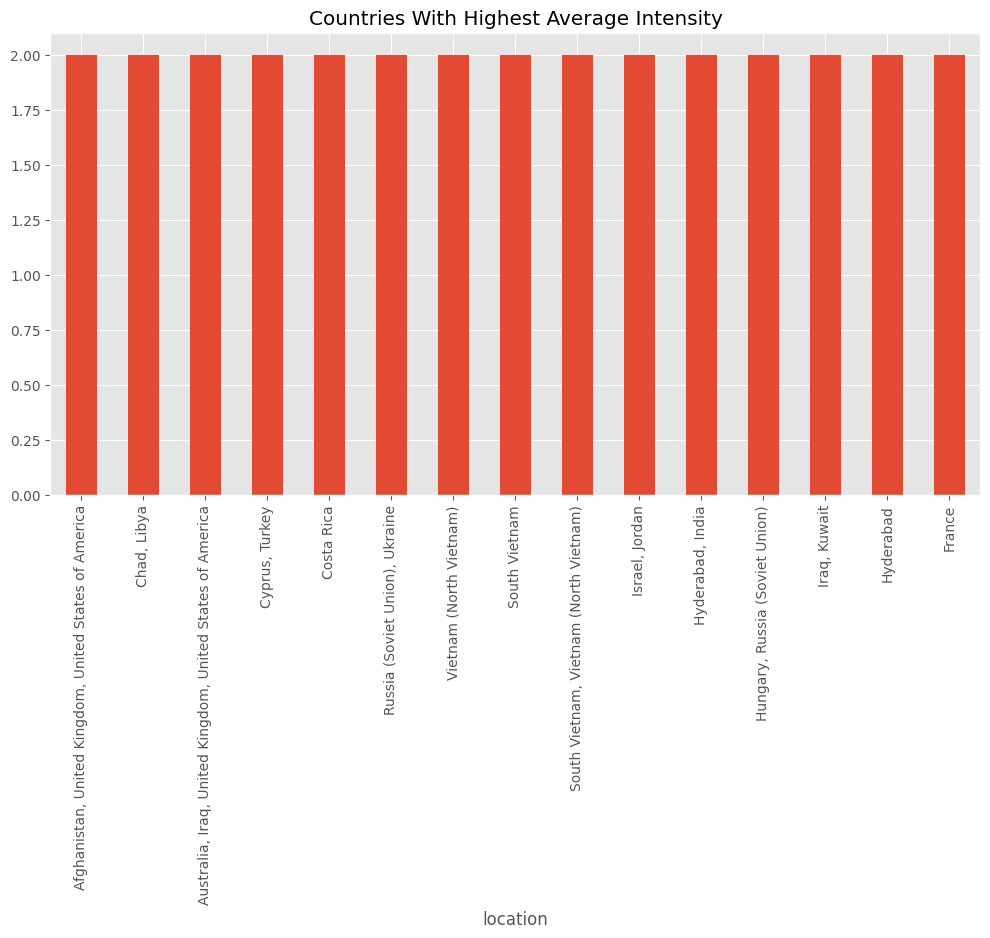

In [ ]:
plt.figure(figsize=(12,6))

country_intensity.plot(
    kind='bar'
)

plt.title(
    "Countries With Highest Average Intensity"
)

plt.show()

In [ ]:
region_conflicts = (
    conflict_df.groupby("region")
    .size()
    .sort_values(ascending=False)
)

region_conflicts

,0
region,
3,1098
4,934
2,410
5,204
1,156
"1, 3",4
"1, 2",4
"1, 2, 5",2
"1, 2, 3, 5",1


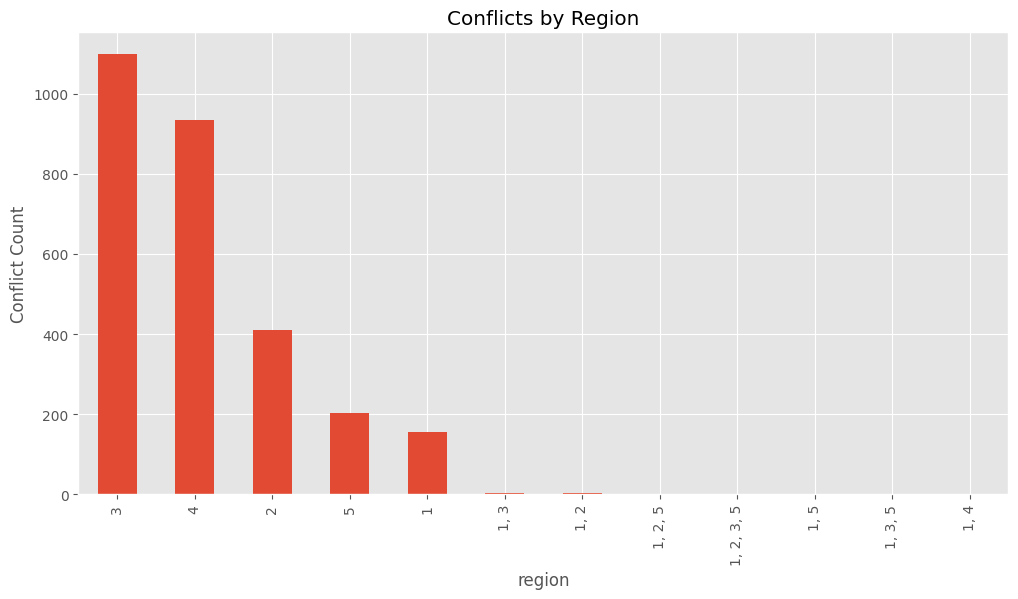

In [ ]:
plt.figure(figsize=(12,6))

region_conflicts.plot(kind="bar")

plt.title("Conflicts by Region")

plt.ylabel("Conflict Count")

plt.show()

In [ ]:
conflict_df["type_of_conflict"].value_counts()

,count
type_of_conflict,
3,2037
4,507
2,155
1,117


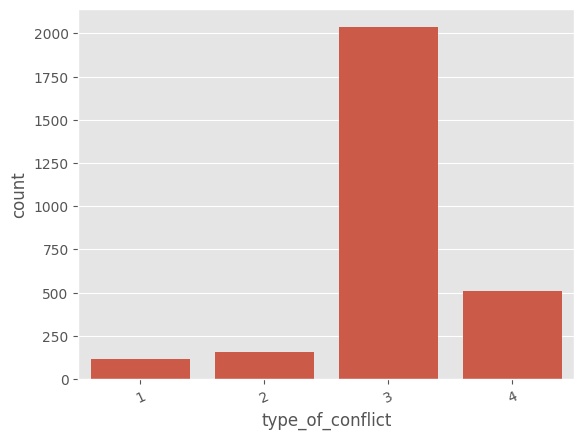

In [ ]:
sns.countplot(
    data=conflict_df,
    x="type_of_conflict"
)

plt.xticks(rotation=25)

plt.show()

In [ ]:
conflict_df["side_a"].value_counts().head(20)

,count
side_a,
Government of Myanmar (Burma),308
Government of India,218
Government of Ethiopia,138
Government of Philippines,122
Government of Israel,89
Government of Iraq,69
Government of Iran,68
Government of Afghanistan,63
Government of Colombia,62


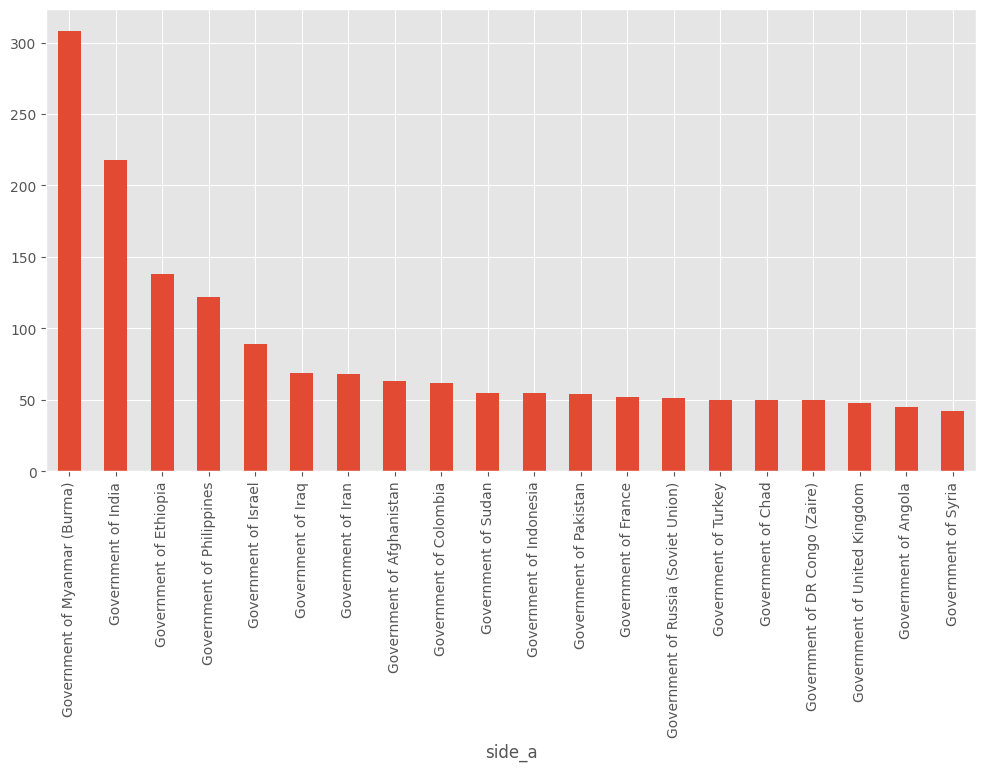

In [ ]:
plt.figure(figsize=(12,6))

conflict_df["side_a"].value_counts().head(20).plot(kind="bar")

plt.show()

In [ ]:
conflict_df["side_b"].value_counts().head(20)

,count
side_b,
IS,167
CPP,52
KIO,46
PKK,41
Kashmir insurgents,36
KNU,35
CPB,34
OLF,34
Government of Pakistan,30


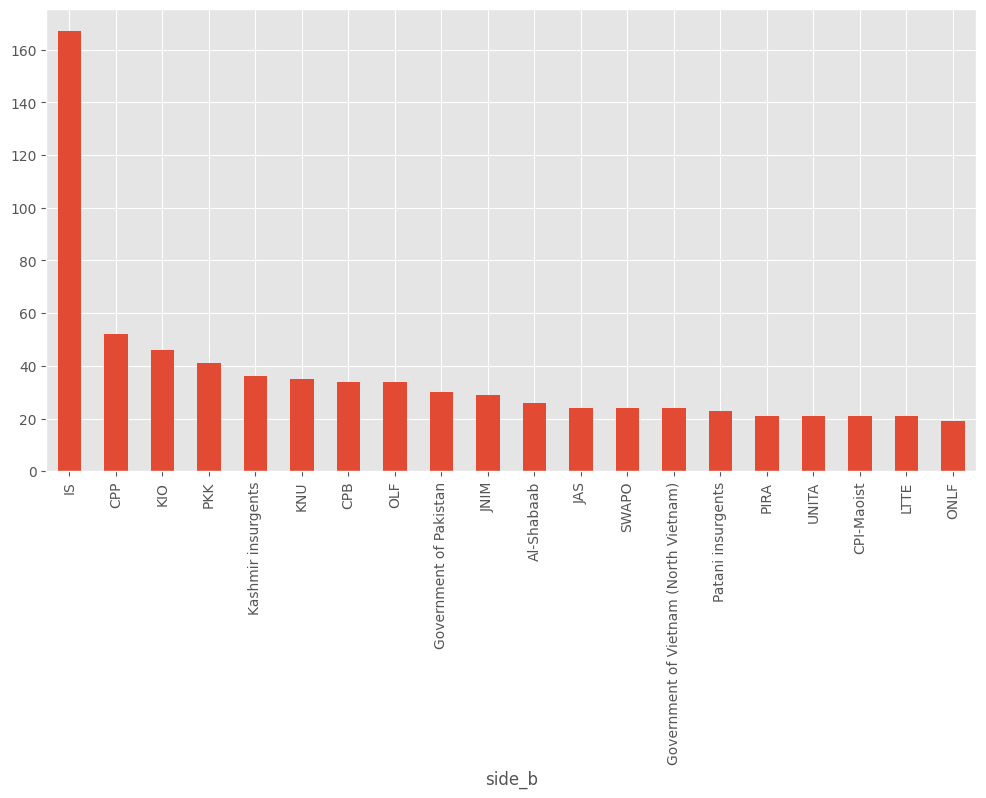

In [ ]:
plt.figure(figsize=(12,6))

conflict_df["side_b"].value_counts().head(20).plot(kind="bar")

plt.show()

In [ ]:
conflict_df["start_date"] = pd.to_datetime(conflict_df["start_date"])

conflict_df["ep_end_date"] = pd.to_datetime(conflict_df["ep_end_date"])

In [ ]:
conflict_df["Conflict_Duration_Days"] = (
    conflict_df["ep_end_date"] -
    conflict_df["start_date"]
).dt.days

In [ ]:
conflict_df[
    [
        "location",
        "Conflict_Duration_Days"
    ]
].sort_values(
    "Conflict_Duration_Days",
    ascending=False
).head(20)

,location,Conflict_Duration_Days
330,Myanmar (Burma),26597.0
42,Iran,26432.0
167,"India, Pakistan",26297.0
289,Myanmar (Burma),26227.0
588,Israel,26115.0
41,Iran,25771.0
481,Myanmar (Burma),25535.0
286,Myanmar (Burma),24729.0
586,Israel,24329.0
585,Israel,23568.0


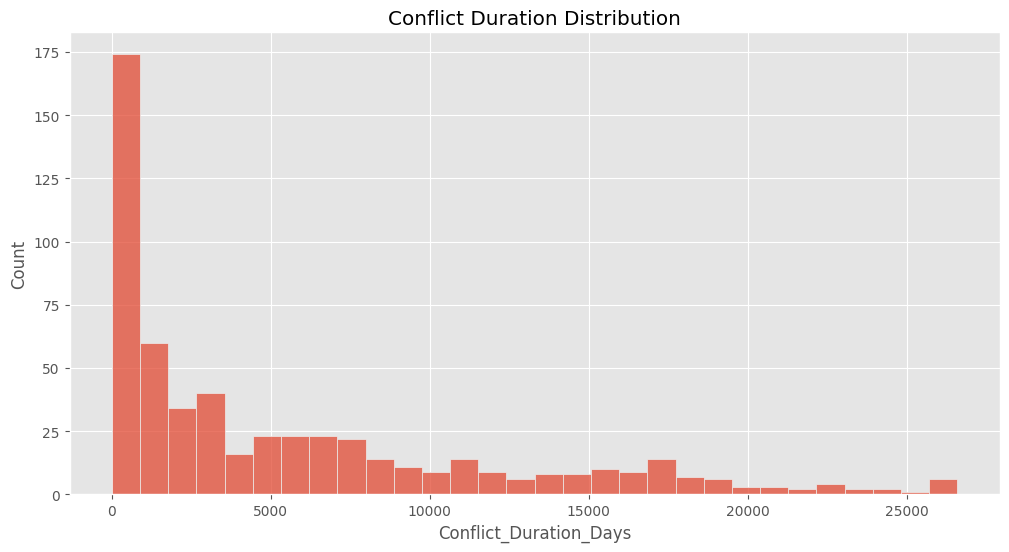

In [ ]:
plt.figure(figsize=(12,6))

sns.histplot(
    conflict_df["Conflict_Duration_Days"],
    bins=30
)

plt.title("Conflict Duration Distribution")

plt.show()

In [ ]:
first_year = conflict_df['year'].min()

latest_year = conflict_df['year'].max()

print(first_year)
print(latest_year)

1946
2025


In [ ]:
conflict_df['Decade'] = (
    conflict_df['year']//10
)*10

decade_data = (
    conflict_df.groupby('Decade')
    .size()
    .reset_index(name='Conflict_Count')
)

decade_data

,Decade,Conflict_Count
0,1940,72
1,1950,158
2,1960,244
3,1970,312
4,1980,421
5,1990,448
6,2000,354
7,2010,457
8,2020,350


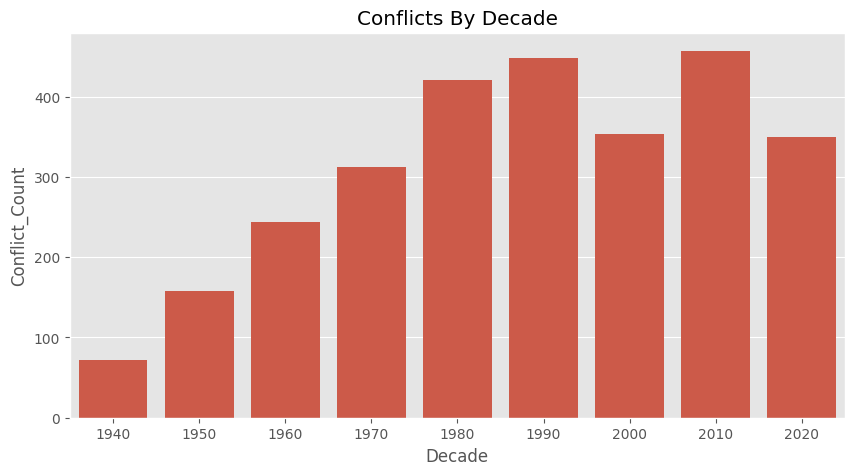

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=decade_data,
    x='Decade',
    y='Conflict_Count'
)

plt.title(
    "Conflicts By Decade"
)

plt.show()

In [ ]:
top_country_table = (
    conflict_df['location']
    .value_counts()
    .reset_index()
)

top_country_table.columns = [
    'Country',
    'Conflict_Count'
]

top_country_table.head(20)

,Country,Conflict_Count
0,Myanmar (Burma),308
1,India,190
2,Ethiopia,134
3,Philippines,122
4,Israel,85
5,Iraq,67
6,Colombia,62
7,Angola,59
8,Afghanistan,59
9,Sudan,55


In [ ]:
print(f"""
Total Conflicts : {conflict_df['conflict_id'].nunique()}

Countries : {conflict_df['location'].nunique()}

Regions : {conflict_df['region'].nunique()}

Most Affected Country :
{conflict_df['location'].value_counts().idxmax()}

Most Affected Region :
{region_conflicts.idxmax()}

Longest Conflict :
{conflict_df.loc[conflict_df['Conflict_Duration_Days'].idxmax(),'location']}
""")


Total Conflicts : 303

Countries : 165

Regions : 12

Most Affected Country :
Myanmar (Burma)

Most Affected Region :
3

Longest Conflict :
Myanmar (Burma)



In [ ]:
yearly_conflicts.to_csv(
    "yearly_conflicts.csv",
    index=False
)

region_conflicts.to_csv(
    "regional_conflicts.csv"
)

print("Phase 2 Completed Successfully")

Phase 2 Completed Successfully


In [ ]:
conflict_df.columns.tolist()

['conflict_id',
 'location',
 'side_a',
 'side_a_id',
 'side_a_2nd',
 'side_b',
 'side_b_id',
 'side_b_2nd',
 'incompatibility',
 'territory_name',
 'year',
 'intensity_level',
 'cumulative_intensity',
 'type_of_conflict',
 'start_date',
 'start_prec',
 'start_date2',
 'start_prec2',
 'ep_end',
 'ep_end_date',
 'ep_end_prec',
 'gwno_a',
 'gwno_a_2nd',
 'gwno_b',
 'gwno_b_2nd',
 'gwno_loc',
 'region',
 'version',
 'Decade']